# Superstore EDA (Sample - Superstore.xlsm)

This notebook performs:
- data loading from Excel sheets (`Orders`, `Returns`, `People`)
- data cleaning and quality checks
- exploratory data analysis and visualizations
- business insights for sales, profit, and returns


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

file_path = Path(r"e:/temp/Data Visualization/Sample - Superstore.xlsm")
orders = pd.read_excel(file_path, sheet_name="Orders")
returns = pd.read_excel(file_path, sheet_name="Returns")
people = pd.read_excel(file_path, sheet_name="People")

print("Orders:", orders.shape)
print("Returns:", returns.shape)
print("People:", people.shape)
orders.head()

Orders: (9997, 21)
Returns: (296, 2)
People: (7, 2)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 1) Clean and prepare data

In [8]:
df = orders.copy()

# standardize column names
df.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in df.columns]
returns.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in returns.columns]
people.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in people.columns]

# remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# parse dates
for c in ["Order_Date", "Ship_Date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# coerce numerics
for c in ["Sales", "Quantity", "Discount", "Profit"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# fill key numeric nulls with medians
for c in ["Sales", "Quantity", "Discount", "Profit"]:
    df[c] = df[c].fillna(df[c].median())

# remove invalid values
df = df[(df["Sales"] >= 0) & (df["Quantity"] > 0)]

# trim important categorical columns
for c in ["Category", "Sub_Category", "Region", "Segment", "Ship_Mode", "State", "City"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

print("Cleaned shape:", df.shape)
print("Nulls remaining (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))
df.head()

Cleaned shape: (9997, 21)
Nulls remaining (top 10):
Row_ID          0
Postal_Code     0
Discount        0
Quantity        0
Sales           0
Product_Name    0
Sub_Category    0
Category        0
Product_ID      0
Region          0
dtype: int64


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2) Univariate and bivariate exploration

C:\Users\msrau\AppData\Local\Temp\ipykernel_15100\2622767866.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_category, x="Category", y="Sales", ax=axes[0, 0], palette="Blues_d")
C:\Users\msrau\AppData\Local\Temp\ipykernel_15100\2622767866.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profit_by_region, x="Region", y="Profit", ax=axes[0, 1], palette="Greens_d")


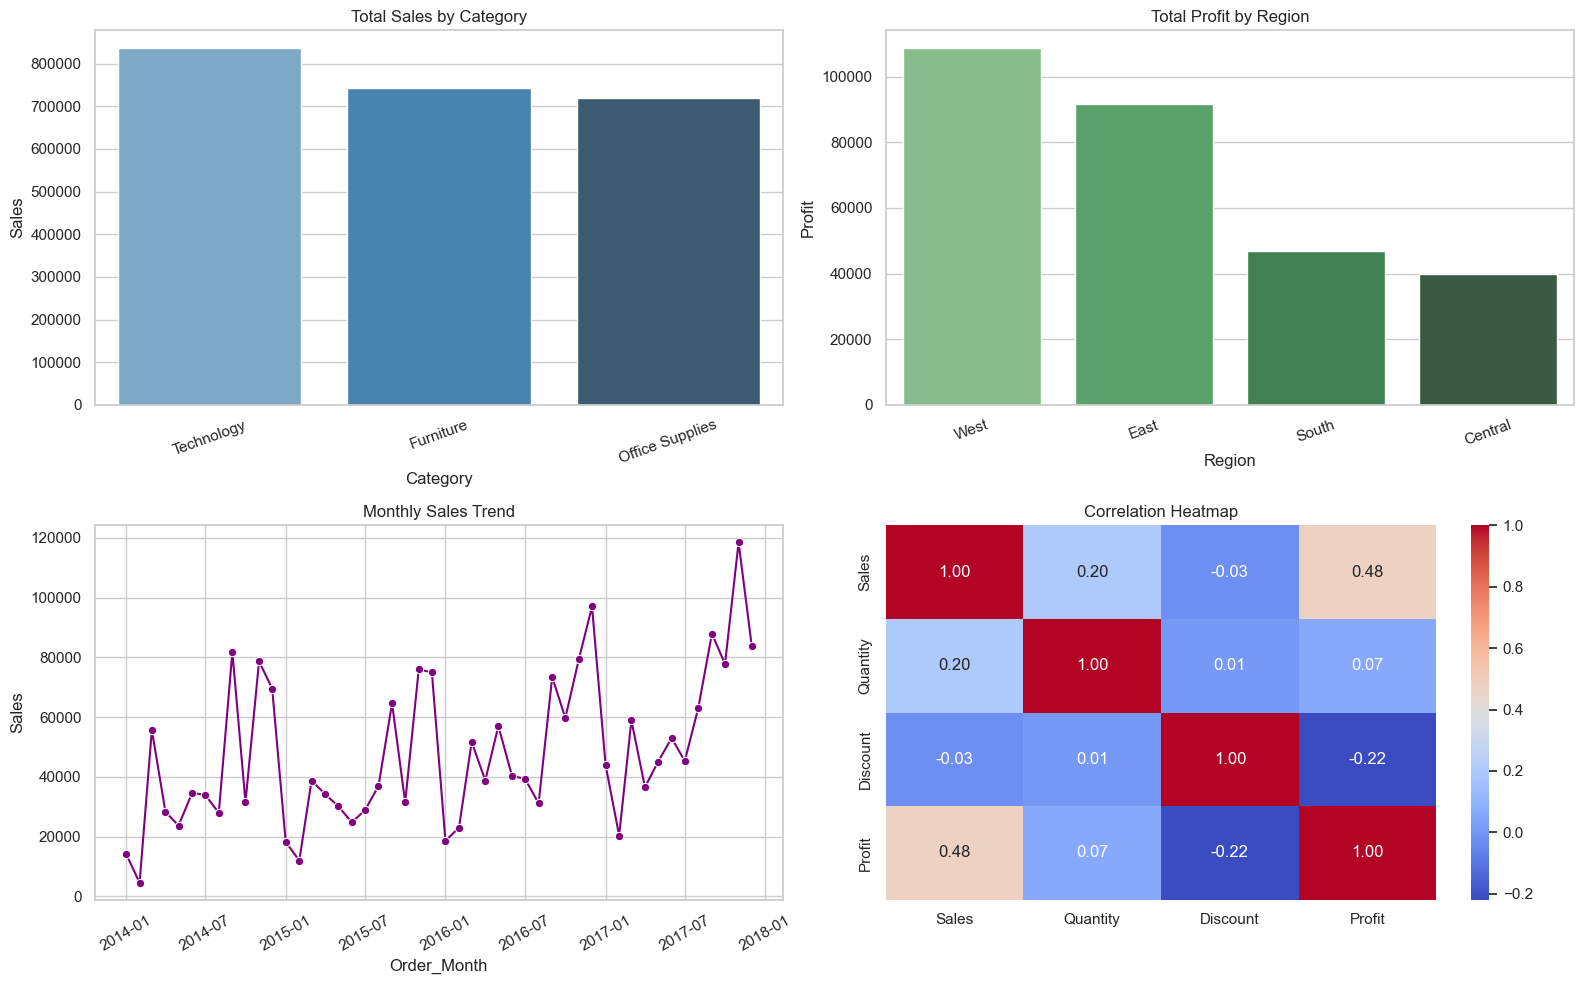

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sales_by_category = df.groupby("Category", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
profit_by_region = df.groupby("Region", as_index=False)["Profit"].sum().sort_values("Profit", ascending=False)

df["Order_Month"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()
monthly_sales = df.groupby("Order_Month", as_index=False)["Sales"].sum().sort_values("Order_Month")

sns.barplot(data=sales_by_category, x="Category", y="Sales", ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("Total Sales by Category")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.barplot(data=profit_by_region, x="Region", y="Profit", ax=axes[0, 1], palette="Greens_d")
axes[0, 1].set_title("Total Profit by Region")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.lineplot(data=monthly_sales, x="Order_Month", y="Sales", marker="o", ax=axes[1, 0], color="purple")
axes[1, 0].set_title("Monthly Sales Trend")
axes[1, 0].tick_params(axis="x", rotation=30)

corr = df[["Sales", "Quantity", "Discount", "Profit"]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## 3) Return analysis (join Orders with Returns)

Return rate: 8.01%
Profit (returned orders): $23,305.31
Profit (non-returned orders): $263,310.56


C:\Users\msrau\AppData\Local\Temp\ipykernel_15100\4058712224.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged, x="Returned_Flag", palette="Set2")


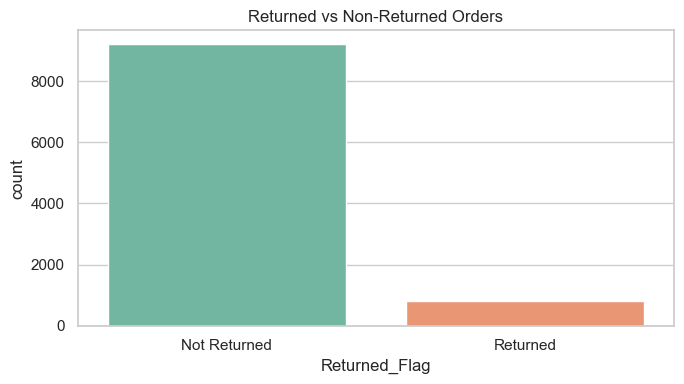

In [10]:
merged = df.merge(
    returns[["Order_ID"]].drop_duplicates().assign(Returned_Flag=1),
    on="Order_ID",
    how="left"
)
merged["Returned_Flag"] = merged["Returned_Flag"].fillna(0).astype(int)

return_rate = merged["Returned_Flag"].mean() * 100
profit_returned = merged.loc[merged["Returned_Flag"] == 1, "Profit"].sum()
profit_non_returned = merged.loc[merged["Returned_Flag"] == 0, "Profit"].sum()

print(f"Return rate: {return_rate:.2f}%")
print(f"Profit (returned orders): ${profit_returned:,.2f}")
print(f"Profit (non-returned orders): ${profit_non_returned:,.2f}")

plt.figure(figsize=(7, 4))
sns.countplot(data=merged, x="Returned_Flag", palette="Set2")
plt.title("Returned vs Non-Returned Orders")
plt.xticks([0, 1], ["Not Returned", "Returned"])
plt.tight_layout()
plt.show()

## 4) Key business insights

In [11]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100 if total_sales else np.nan

best_category = df.groupby("Category")["Profit"].sum().idxmax()
worst_category = df.groupby("Category")["Profit"].sum().idxmin()
best_region = df.groupby("Region")["Profit"].sum().idxmax()
worst_region = df.groupby("Region")["Profit"].sum().idxmin()

print("--- KPI Summary ---")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Best Category (by profit): {best_category}")
print(f"Weakest Category (by profit): {worst_category}")
print(f"Best Region (by profit): {best_region}")
print(f"Weakest Region (by profit): {worst_region}")

print("\nRecommended actions:")
print("1) Reduce deep discounts where profit is consistently weak.")
print("2) Focus campaigns on high-profit categories and regions.")
print("3) Investigate return-heavy segments to protect margin.")

--- KPI Summary ---
Total Sales: $2,297,961.17
Total Profit: $286,615.87
Profit Margin: 12.47%
Best Category (by profit): Technology
Weakest Category (by profit): Furniture
Best Region (by profit): West
Weakest Region (by profit): Central

Recommended actions:
1) Reduce deep discounts where profit is consistently weak.
2) Focus campaigns on high-profit categories and regions.
3) Investigate return-heavy segments to protect margin.


## 5) Optional: regional manager lookup (People sheet)

The `People` sheet maps regions to managers; use this table to assign ownership for low-performing regions.

In [12]:
people.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in people.columns]
people.head()

,Person,Region
0,Anna Andreadi,West
1,Chuck Magee,East
2,Kelly Williams,Central
3,Cassandra Brandow,South
4,Ram,South-East


## 6) Additional visualizations

C:\Users\msrau\AppData\Local\Temp\ipykernel_15100\3452467947.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="Profit", ax=axes[1], palette="Set2")


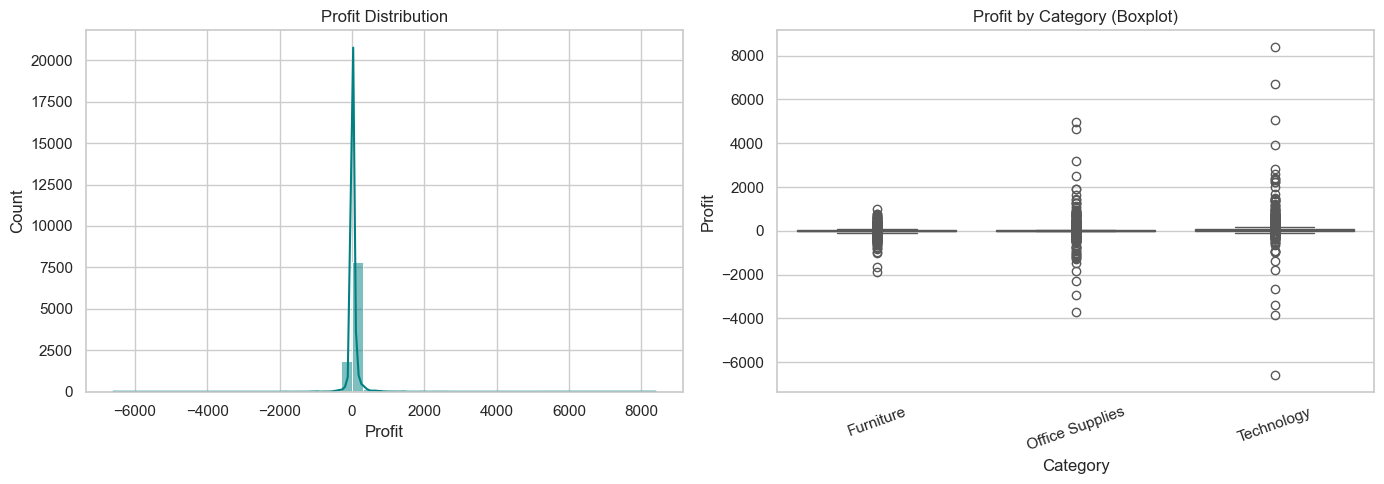

In [13]:
# 6.1 Profit distribution and outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Profit"], bins=50, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Profit Distribution")
axes[0].set_xlabel("Profit")

sns.boxplot(data=df, x="Category", y="Profit", ax=axes[1], palette="Set2")
axes[1].set_title("Profit by Category (Boxplot)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

C:\Users\msrau\AppData\Local\Temp\ipykernel_15100\3745787013.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_sales, x="Sales", y="Sub_Category", ax=axes[0], palette="Blues_r")
C:\Users\msrau\AppData\Local\Temp\ipykernel_15100\3745787013.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_profit, x="Profit", y="Sub_Category", ax=axes[1], palette="Greens_r")


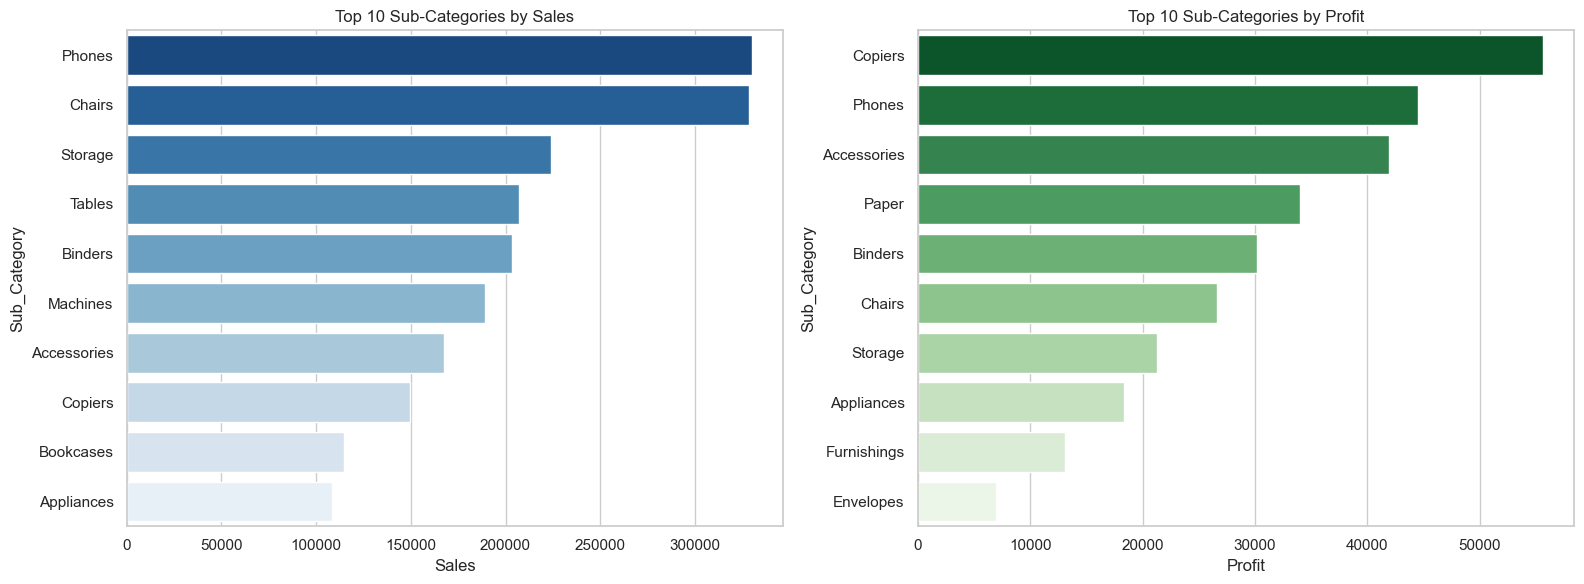

In [14]:
# 6.2 Top sub-categories by Sales and Profit
subcat_sales = df.groupby("Sub_Category", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False).head(10)
subcat_profit = df.groupby("Sub_Category", as_index=False)["Profit"].sum().sort_values("Profit", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=subcat_sales, x="Sales", y="Sub_Category", ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 10 Sub-Categories by Sales")

sns.barplot(data=subcat_profit, x="Profit", y="Sub_Category", ax=axes[1], palette="Greens_r")
axes[1].set_title("Top 10 Sub-Categories by Profit")

plt.tight_layout()
plt.show()

C:\Users\msrau\AppData\Local\Temp\ipykernel_15100\3246346429.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ship_summary, x="Ship_Mode", y="Sales", ax=axes[0], palette="mako")
C:\Users\msrau\AppData\Local\Temp\ipykernel_15100\3246346429.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x="Segment", y="Profit", ax=axes[1], palette="viridis")


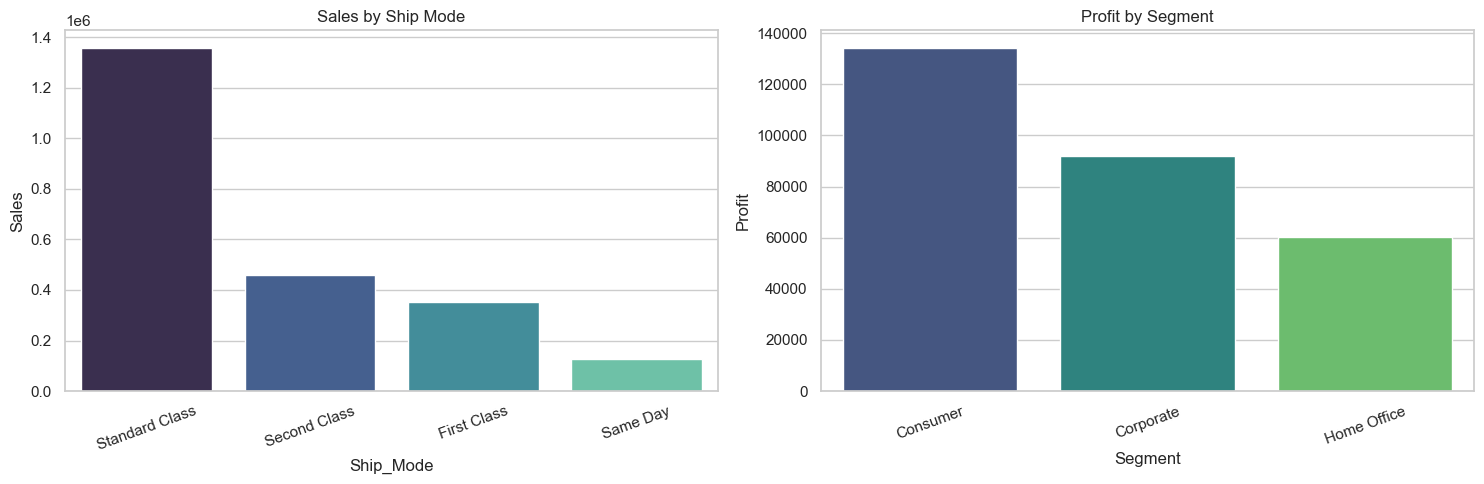

,Ship_Mode,Sales,Profit,Orders
3,Standard Class,1.358216e+06,164088.7875,2994
2,Second Class,4.599539e+05,57665.4794,967
0,First Class,3.514284e+05,48969.8399,787
1,Same Day,1.283631e+05,15891.7589,264


In [15]:
# 6.3 Shipping mode and segment analysis
ship_summary = df.groupby("Ship_Mode", as_index=False).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique")
).sort_values("Sales", ascending=False)

segment_summary = df.groupby("Segment", as_index=False).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_values("Sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=ship_summary, x="Ship_Mode", y="Sales", ax=axes[0], palette="mako")
axes[0].set_title("Sales by Ship Mode")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=segment_summary, x="Segment", y="Profit", ax=axes[1], palette="viridis")
axes[1].set_title("Profit by Segment")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

ship_summary

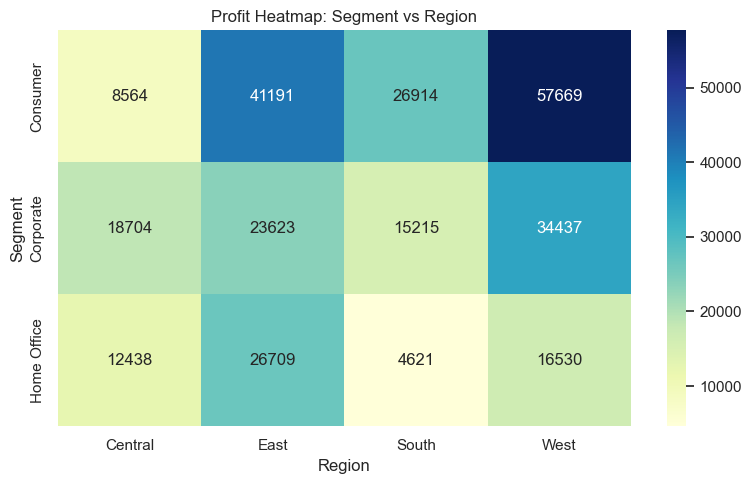

In [16]:
# 6.4 Segment vs Region profitability heatmap
pivot_profit = df.pivot_table(
    index="Segment",
    columns="Region",
    values="Profit",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_profit, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Profit Heatmap: Segment vs Region")
plt.tight_layout()
plt.show()

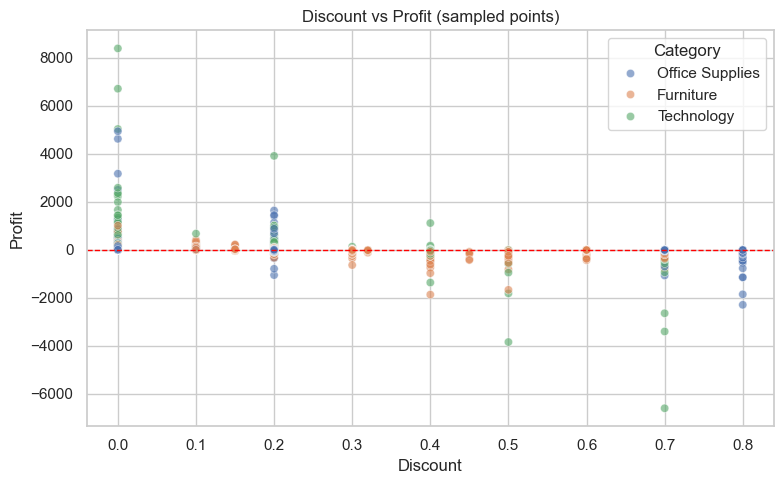

Correlation (Discount, Profit): -0.22


In [17]:
# 6.5 Discount vs Profit relationship
sample_df = df.sample(min(6000, len(df)), random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample_df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.6
)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Discount vs Profit (sampled points)")
plt.tight_layout()
plt.show()

print("Correlation (Discount, Profit):", df[["Discount", "Profit"]].corr().iloc[0, 1].round(3))

## 7) Interpretation notes

- Use the **sub-category charts** to identify where high sales do not translate to high profit.
- Use the **segment-region heatmap** to prioritize regional strategy by customer segment.
- Use the **discount-profit scatter** to detect discount thresholds where margin erosion starts.
- Use the **ship mode summary** to evaluate service-level and profitability trade-offs.